# ML을 위한 선형대수학

## 1. 행렬 표현
- 2 x 2 행렬
  - np.array([[0,0],[0,0]])

In [2]:
import numpy as np

In [3]:
A = np.array([1, 30, 2, 50])

print(A)

[ 1 30  2 50]


## 2. 회전행렬

In [ ]:

from PIL import Image

# 1. PNG 이미지 열기
image_path = "/content/poketball.png"  # 여기에 본인의 이미지 경로를 입력하세요
output_path = "/content/rotate_poketball.png"
img = Image.open(image_path)

# 2. NumPy array로 변환
img_array = np.array(img)
rows, cols, channels = img_array.shape

# 결과 확인
print("이미지 차원(Shape):", img_array.shape)
print("데이터 타입(dtype):", img_array.dtype)

R = np.array([[0, 1],
              [-1, 0]])

new_rows = cols
new_cols = rows
rotated_array = np.zeros((new_rows, new_cols, channels), dtype=np.uint8)

for r in range(rows):
      for c in range(cols):
        # 원본 좌표 (r, c)를 열벡터로 정의
        point = np.array([[r],
                          [c]])

        # 회전 행렬곱 수행 (R @ point)
        rotated_point = R @ point

        # 새로운 좌표 계산: (r, c) -> (c, rows - 1 - r) (이미지 좌표계 기준)
        new_r = c
        new_c = rows - 1 - r

        # 회전된 좌표가 범위 내에 있는지 확인 (경계 조건 처리)
        if 0 <= new_r < new_rows and 0 <= new_c < new_cols:
          rotated_array[new_r, new_c] = img_array[r, c]

print(f"회전된 이미지를 '{output_path}'에 저장하는 중...")
rotated_img = Image.fromarray(rotated_array)
rotated_img.save(output_path)
print("완료되었습니다!")

## 3. 연립방정식

- 행렬의 곱 : A @ B
- 역행렬 : np.linalg.inv(A)

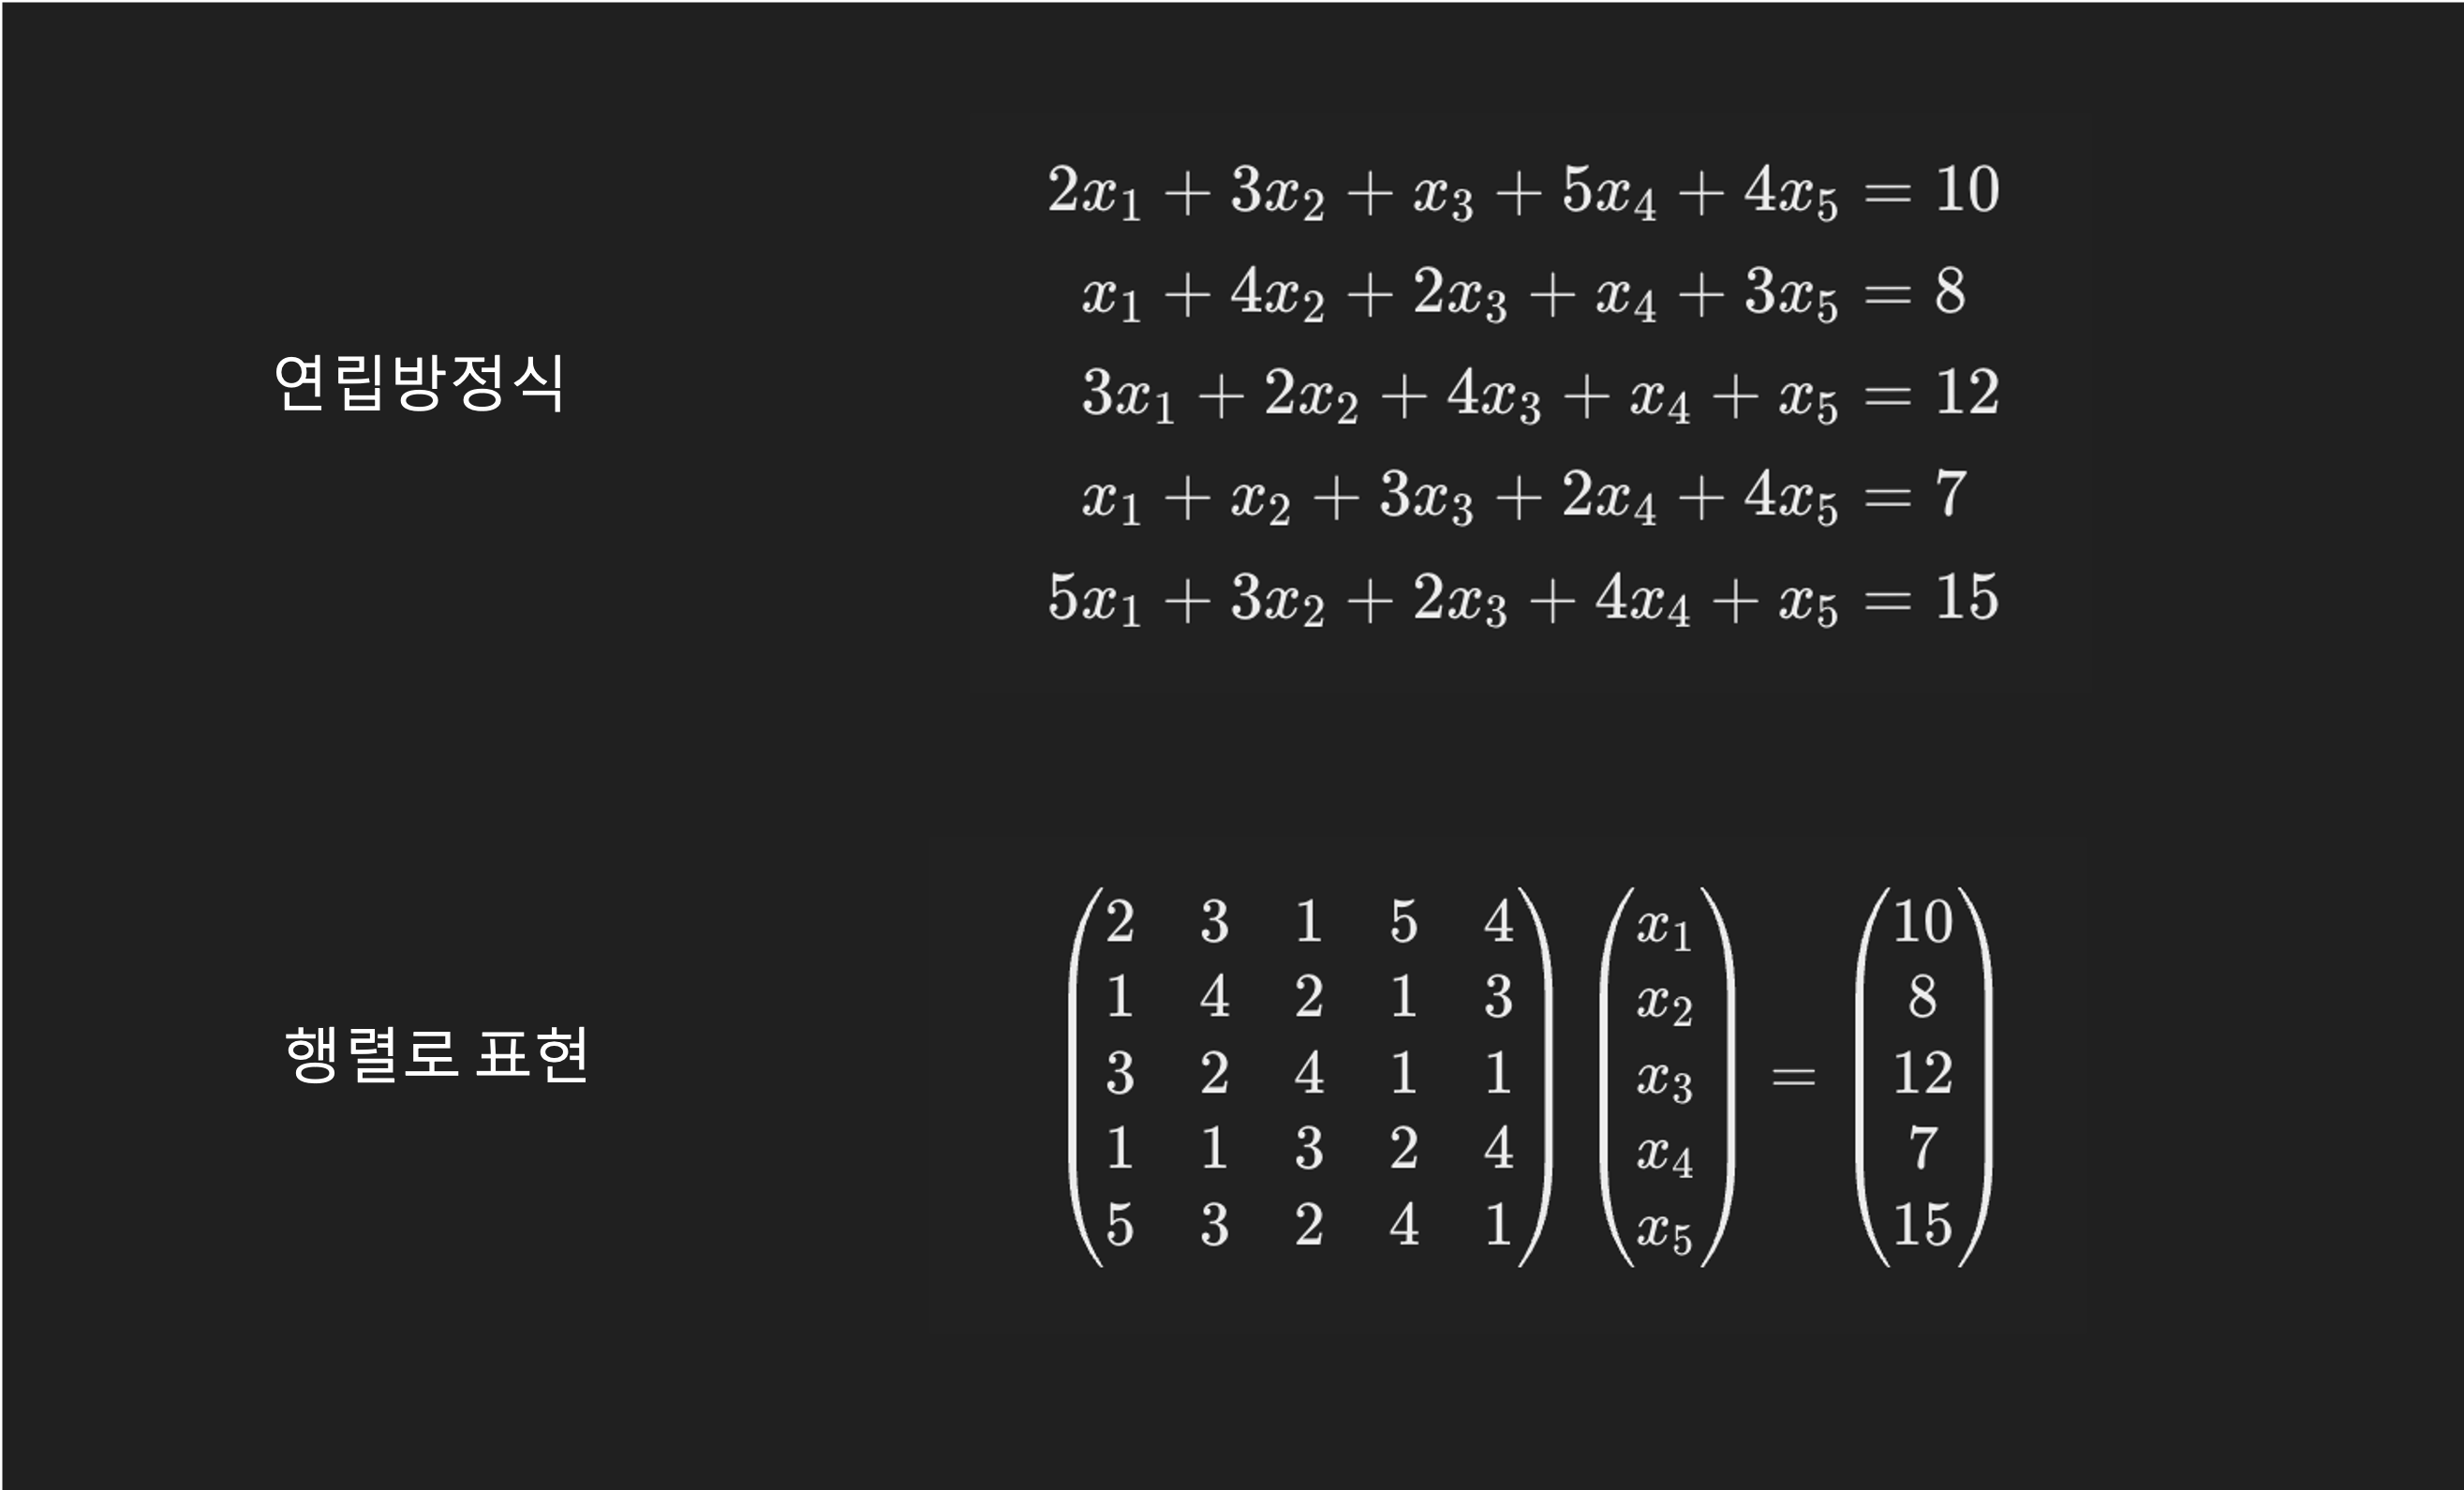

In [4]:
A = np.array([[2, 3, 1, 5, 4],
              [1, 4, 2, 1, 3],
              [3, 2, 4, 1, 1],
              [1, 1, 3, 2, 4],
              [5, 3, 2, 4, 1]])

result = np.array([[10],
                   [8],
                   [12],
                   [7],
                   [15]])

A_inv = np.linalg.inv(A)

X = A_inv @ result

print(X)

[[ 1.04]
 [ 1.04]
 [ 1.56]
 [ 1.  ]
 [-0.44]]


In [5]:
# 새로운 데이터(벡터)로 결과값 예측

B = [3, 5, 6, 7, 1]
result = B @ X

print(result)

[24.24]


In [6]:
# 벡터의 방향과 크기
C = np.array([2, 3, 1, 5, 4])

result = C @ X
print(result)

D = np.array([4, 6, 2, 10, 8])

result = D @ X
print(result)

[10.]
[20.]


In [7]:
# 두 벡터의 방향이 같은지 확인 (오차 허용)
cos_theta = np.dot(C, D) / (np.linalg.norm(C) * np.linalg.norm(D))
is_same_direction = np.isclose(cos_theta, 1.0)

print(f"코사인 유사도: {cos_theta:.4f}")
print(f"방향이 같은가? {is_same_direction}")

# --> 방향이 같은 벡터 + 크기만 다르다.
# 크기를 뽑아내는 작업을 Magnitude, Norm 이라고 한다.
# 일차종속, 일차독립

코사인 유사도: 1.0000
방향이 같은가? True


### 알고가자 벡터 지식

- 행렬 = 벡터의 집합

- X = [1, 2, 3, 4, 5] , Y = [5, 4, 3, 2, 1]

- 백터의 내적 = <X,Y>
  - (1 * 5 + 2 * 4 + ... )
  - np.dot(A, B)
  - 행 X 열 구조에선 A @ B 가능
  - 두 벡터의 관계를 숫자로 표현

- 벡터의 노름 = | | X | |
  - ||X|| = <X, X>
  - (1 * 1 + 2 * 2 + ... )
  - 자신의 크기를 숫자로 표현

## 4. 행렬의 차원과 Rank

In [8]:
test_a = np.array([1,2,3])
test_b = np.array([2,4,-2])
raw_rank = np.linalg.matrix_rank(test_a @ test_b)

print(raw_rank)

1


In [9]:
X_raw = np.array([
    [25,  2, 300,  50,  350],  # 직원 A
    [30,  7, 450,  60,  510],  # 직원 B
    [35, 12, 600,  80,  680],  # 직원 C
    [40, 17, 750, 100,  850],  # 직원 D
    [45, 22, 900, 120, 1020]   # 직원 E
], dtype=float)

print(X_raw.shape) # 출력: (5, 5) (5행 5열)
print(X_raw.size)  # 출력: 25 (총 25개)

# Rank 계산
raw_rank = np.linalg.matrix_rank(X_raw)

print(f"현재 행렬의 Rank: {raw_rank}")

(5, 5)
25
현재 행렬의 Rank: 3


## 5. 행렬의 대각화, 고유벡터, 고유값

In [10]:
# 행렬의 대각화

A = np.array([[3,1], [1,3]])

D, P = np.linalg.eig(A)

print(f"고유값 확인 : {D}")
print(f"고유벡터 확인 : \n{P}")

고유값 확인 : [4. 2.]
고유벡터 확인 : 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [11]:
# 대각화를 활용한 압축행렬 도출

_D = np.array([[4,0],[0,0]])
P_inv = np.linalg.inv(P)
_A = P @ _D @ P_inv

print(_A)

[[2. 2.]
 [2. 2.]]


In [12]:
# 특이값 분해(SVD)
A = np.array([[3,1], [1,3], [2,2]])

u, s, vh = np.linalg.svd(A)

print(f"좌 특이벡터 : {u}")
print(f"고유값 : {s}")
print(f"우 특이벡터 : {vh}")

좌 특이벡터 : [[-5.77350269e-01  7.07106781e-01 -4.08248290e-01]
 [-5.77350269e-01 -7.07106781e-01 -4.08248290e-01]
 [-5.77350269e-01  2.01032697e-16  8.16496581e-01]]
고유값 : [4.89897949 2.        ]
우 특이벡터 : [[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


## 6. 행렬식
- np.linalg.det


In [13]:
det_A = np.array([[5, 1, 1], [1, 5, 1], [1, 1, 5]])

d = np.linalg.det(det_A)
print(d)

111.99999999999996
